# **ROUGH VOLATILITY**
---

<img src="Imperial_logo.png" align = "left" width=200>
 <br>
 
- Copyright (c) Jack Jacquier, 2026. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.13

$$\newcommand{\D}{\mathrm{d}}$$
$$\newcommand{\RR}{\mathbb{R}}$$
$$\newcommand{\PP}{\mathbb{P}}$$
$$\newcommand{\QQ}{\mathbb{Q}}$$
$$\newcommand{\EE}{\mathbb{E}}$$
$$\newcommand{\VV}{\mathbb{V}}$$
$$\newcommand{\VIX}{\mathrm{VIX}}$$
$$\newcommand{\Ff}{\mathcal{F}}$$
$$\newcommand{\Ee}{\mathcal{E}}$$
$$\newcommand{\half}{\frac{1}{2}}$$

In [1]:
import warnings; warnings.simplefilter('ignore')
import datetime as dt
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import zipfile as zi 
from io import StringIO, BytesIO
import requests
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import norm
%matplotlib inline
pd.core.common.is_list_like = pd.api.types.is_list_like
from datetime import datetime
from math import factorial

# Summary (from previous session): modelling under $\PP$

$$
\frac{\mathrm{d}S_t}{S_t} = \mu_{t} \mathrm{d} t + \sigma_t \mathrm{d}W_t, \qquad t\geq 0,
$$
for some standard Brownian motion $(W_t)_{t\geq 0}$.

- Distributions of differences in the log of realised volatility are close to Gaussian.
- This motivates us to model $\sigma_t$ as a lognormal random variable.
- Moreover, the scaling property of variance of RV differences suggests the model:
$$
\log \sigma_{t+\Delta} - \log \sigma_t =\nu\,\Big( B^H_{t+\Delta}-B^H_t\Big)
$$
where $B^H$ is fractional Brownian motion.

# Fractional Brownian motion

- *Fractional Brownian motion* (fBm) $\{B^H_t; t \in \RR\}$ is a centered Gaussian process:
$$
\EE\Big[B^H_t\Big] = 0
\qquad\text{and}\qquad
B^H_t \sim\mathcal{N}\left(0, t^{2H}\right),
\quad\text{for all }t\geq 0,
$$
starting at $B_{0}^{H} = 0$, with autocovariance function
$$
\EE\Big[B^H_t B^H_s\Big] = \frac{1}{2}\,\Big\{ |t|^{2\,H}+|s|^{2\,H}-|t-s|^{2\,H} \Big\},
$$
where $H \in (0,1)$ is called the *Hurst index* or parameter.

## Properties:
**Dependence of increments**

From this definition, for any $s_1<t_1<s_2<t_2$,
\begin{equation*}
\mathbb{E}\Big[\left(B^H_{t_1} - B^H_{s_1}\right)\left(B^H_{t_2} - B^H_{s_2}\right)\Big]\quad
\left\{
\begin{array}{l}
<0,  \text{ for }H \in \left(0,\frac{1}{2}\right),\\
>0,  \text{ for }H \in \left(\frac{1}{2}, 1\right), \\
=0,  \text{ for }H =\frac{1}{2}.
\end{array}
\right.
\end{equation*}
   - In particular, when $H=\frac{1}{2}$, fBm corresponds to a standard Brownian motion (independent increments).
   - If $H>\frac{1}{2}$, increments are positively correlated, so the process is trending.
   - If $H<\frac{1}{2}$, increments are negatively correlated, so the process is reverting.

 
**Self-similarity**: $\text{Law}(B^H_{at}) = \text{Law}(a^H B^H_{t})$, for any $a,t\geq 0$;

**Stationary increments**: $\text{Law}(B^H_{t} - B^H_{s}) = \text{Law}(B^H_{t-s})$;

**Continuity**: the paths of $B^H$ are $\gamma$-Holder continuous for any $\gamma \in (0,H)$ (follows from *Kolmogorov-Centsov* continuity theorem).

## Paths of fractional Brownian motion

We simulate the paths of fractional Brownian motion on a daily time grid.

Consider a time window $[0,T]$ and a discretisation $\{t_{i} = i\delta, i=0,\ldots, n\}$ 
with $\delta = \frac{T}{n}$.

We first consider the case of standard Brownian motion, namely $H=\half$.

We can write, for fixed $i \in \{1,\ldots,n\}$,
\begin{align*}
B_{t_i}
& = B _{t_i} -\Big(B _{t_{i-1}} - B _{t_{i-1}}\Big) - \Big(B _{t_{i-2}} - B _{t_{i-2}}\Big) - \cdots -
\Big(B _{t_{2}} - B _{t_{2}}\Big) - \Big(B _{t_{1}} - B _{t_{1}}\Big) - B _{t_{0}},\\
& = \Big(B _{t_i} - B _{t_{i-1}}\Big) + \Big(B _{t_{i-1}} - B _{t_{i-2}}\Big) + \cdots    + \Big(B _{t_{2}} - B _{t_{1}}\Big) + \Big(B _{t_{1}} - B _{t_{0}}\Big),\\
& = \sqrt{\delta}\Big(N_{i} + N_{i-1} - \cdots  + N_{2} + N_{1}\Big),\\
& = \sqrt{\delta} \sum_{j=1}^{i}N_{i}.
\end{align*}
Now, the vector of increments
$\boldsymbol{N} := (N_{1}, N_{2}, \cdots, N_{i-1}, N_{i})^\top$
is Gaussian with covariance matrix, for $i\ne j$,
$$
\EE\left[N_{i}N_{j}\right] = 0, 
$$
and $\EE[N_{i}^2] = 1$, since increments over non-overlapping intervals are independent.
To simulate $B_{t_i}$, we thus simply need to simulate independent Gaussian random variables $N_{1}, \ldots, N_{i}$ and set
$$
B_{t_{i}} = \sqrt{\delta} \sum_{k=1}^{i}N_{k}.
$$
The whole vector $\boldsymbol{B} := (B_{t_{1}}, \ldots, B_{t_{n}})$ is then simulated in $\texttt{python}$ as
$$
\boldsymbol{B} = \sqrt{\delta}\,\texttt{np.cumsum}(\boldsymbol{N}).
$$

In the general fractional case $H\in (0,1)$, we can similarly write
\begin{align*}
B^{H}_{t_i}
& = B^{H}_{t_i} - B^{H}_{t_{i-1}} + B^{H}_{t_{i-1}} - B^{H}_{t_{i-2}}+- \cdots  + B^{H}_{t_{2}} - B^{H}_{t_{1}} + B^{H}_{t_{1}} - B^{H}_{t_{0}},\\
& = \Big(B^{H}_{t_i} - B^{H}_{t_{i-1}}\Big) + \Big(B^{H}_{t_{i-1}} - B^{H}_{t_{i-2}}\Big) + \cdots    + \Big(B^{H}_{t_{2}} - B^{H}_{t_{1}}\Big) + \Big(B^{H}_{t_{1}} - B^{H}_{t_{0}}\Big),\\
& = \sum_{k=1}^{i}\Delta_{k}.
\end{align*}
Now, the vector of increments
$\boldsymbol{\Delta} = \Big(\Delta_{1}, \Delta_{2}, \cdots, \Delta_{i-1}, \Delta_{i}\Big)^\top$
is centered Gaussian: $\EE[\Delta_{k}]=0$ and $\boldsymbol{\Delta} \sim \mathcal{N}(0,\Sigma)$.
But the covariance matrix is more involved: for any $i,j$,
\begin{align*}
\Sigma_{i,j} & := \EE\Big[\Delta_{i}\Delta_{j}\Big]\\
 & = \EE\Big[\Big(B^{H}_{t_{i}} - B^{H}_{t_{i-1}}\Big)\Big(B^{H}_{t_{j}} - B^{H}_{t_{j-1}}\Big)\Big]\\
 & = \half\Big(\Big|(t_{i}-t_{j})+1\Big|^{2H} + \Big|(t_{i}-t_{j})-1\Big|^{2H}\Big) - \Big|t_{i}-t_{j}\Big|^{2H}
 \quad\textit{(exercise)}.
\end{align*}

To simulate $\boldsymbol{\Delta}$, we therefore simulate $\boldsymbol{N}$ from above and note that
$\boldsymbol{\Delta} = \sqrt{\Sigma}\boldsymbol{N}$, where the square root is computed by Cholesky and is such that $\sqrt{\Sigma}$ is an upper diagonal matrix.

The final simulation of $\boldsymbol{B}^{H} := (B^{H}_{t_{1}}, \ldots, B^{H}_{t_{n}})$ is then analogous to the $H=\half$ case:
$$
\boldsymbol{B}^{H} = \texttt{np.cumsum}(\boldsymbol{\Delta}).
$$

**Note:**

Cholesky requires $\mathcal{O}(n^3)$ operations for a square matrix of size $n$.

Faster methods: Hosking, Davies-Harte, hybrid scheme,....

In [2]:
from random import gauss
def covFrac(s, t, H):
    """
    Covariance function of the fractional Brownian motion with Hurst index H
    """
    return 0.5*(np.power(s,2.*H) + np.power(t,2.*H) - np.power(np.abs(t - s),2.*H))
    
def fbm_matrix(T, n, H):
    """
    Constructs paths of fBm with Hurst index H
    on the time grid np.linspace(0., T, n)
    Recall that it starts at 0.
    """
    
    tt = np.linspace(0., T, n)[1:]

    covMatrixFrac = np.matrix([[covFrac(tt[i], tt[j], H) for j in range(n-1)] for i in range(n-1)])
    cholMatFrac = np.linalg.cholesky(covMatrixFrac)
    gaussianVec = np.matrix([np.random.normal(0., 1.) for i in range(n-1)])

    pathFrac = cholMatFrac * gaussianVec.T
    return np.insert(tt, 0, 0.), np.insert(pathFrac.A1, 0, 0.)

*Next cell takes some time to run.....*

In [3]:
HH = [0.1, 0.5, 0.9]
time_period = pd.date_range(start="1/1/2020", end="1/01/2022", freq='B')
deltaT = (time_period.max() - time_period.min()).days / 366.

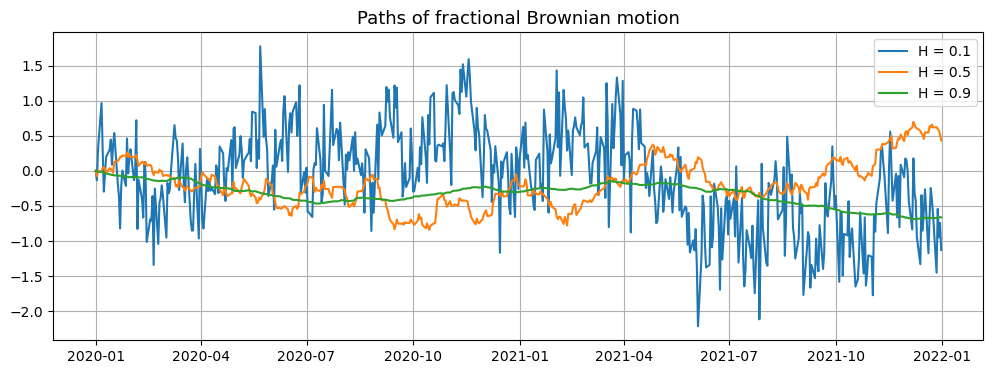

In [4]:
plt.figure(figsize=(12,4))
for H in HH:
    times, fbm = fbm_matrix(deltaT, len(time_period), H)
    plt.plot(time_period, fbm, label="H = %.1f" %H)

plt.title("Paths of fractional Brownian motion", fontsize=13)
plt.legend(loc="best")
plt.grid(True)
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [00:13<00:00,  1.12s/it]


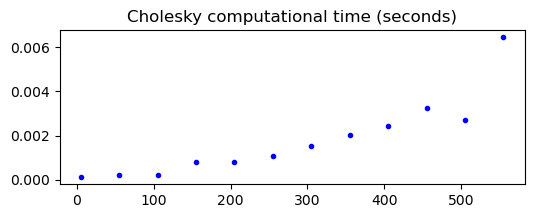

In [7]:
import time
from tqdm import tqdm

def covFrac(s, t, H): ## covariance function    
    return 0.5*(np.power(s,2.*H) + np.power(t,2.*H) - np.power(np.abs(t - s),2.*H))

H = .1
comp_times, nn = [], np.arange(5, 600, 50)
for n in tqdm(nn):
    tt = np.linspace(0., 1., n)[1:]
    covMatrixFrac = np.matrix([[covFrac(tt[i], tt[j], H) for j in range(n-1)] for i in range(n-1)])
    t0 = time.time()
    cholMatFrac = np.linalg.cholesky(covMatrixFrac)
    dt = time.time() - t0
    comp_times.append(dt)

plt.figure(figsize=(6, 2))
plt.plot(nn, comp_times, 'b.')
plt.title("Cholesky computational time (seconds)")
plt.show()

# What about pricing under $\mathbb{Q}$?

<blockquote><div style="background-color:#003399; color:#FFFFFF; font-style: normal;  " ><h4>
Mandelbrot-Van Ness (1968)</h4>
</div>
<div style="background-color:#E8E8E8; color:#000000; font-style: normal; ">
<br>
$$
B^H_t ={C_H}\,\left\{\int_{-\infty}^{t} (t-s)^{H-\frac{1}{2}}\D B_s - \int_{-\infty}^{0} (-s)^{H-\frac{1}{2}}\D B_s\right\}.
$$
<br>

</div>

</blockquote>

where the choice
$$
C_H = \sqrt{\frac{2H\Gamma(\frac{3}{2}-H)}{\Gamma(H+\frac{1}{2})\Gamma(2-2H)}}
$$
ensures that
$$
\mathbb{E}\Big[B^H_t B^H_s\Big] = \frac{1}{2}\Big\{t^{2 H} + s^{2 H} - |t-s|^{2 H}\Big\},
\qquad\text{ for all }s, t \geq 0.
$$


We showed empirically that a good (consistent with data over reasonable timescales) model for the instantaneous volatility $\sigma_t$ read:
\begin{equation}
\log\left(\frac{\sigma_{t+\Delta}}{\sigma_t}\right)
= \nu \left(B^H_{t+\Delta}-B^H_t\right),
\end{equation}
for some fractional Brownian motion $B^H$ and $\nu>0$.

Consider the Mandelbrot-Van Ness representation above,
where we write $B^{\PP}$ instead of $B$ to emphasise that we are for now under the historical probability measure $\PP$.
Then, under $\PP$, we can write, for $0\leq t\leq u$,
letting $\gamma=\half-H$,
\begin{align*}
\log(\sigma^2_u) -\log(\sigma^2_t)
 & = 2\nu {C_H}\left\{\int_{-\infty}^{u} (u-s)^{H-\frac{1}{2}}\D B_s - \int_{-\infty}^{0} (-s)^{H-\frac{1}{2}}\D B_s - \left(\int_{-\infty}^{t} (t-s)^{H-\frac{1}{2}}\D B_s - \int_{-\infty}^{0} (-s)^{H-\frac{1}{2}}\D B_s\right)\right\}\\
 & = 2\nu C_H \left\{\int_{-\infty}^{u} \frac{\D B^{\PP}_s}{(u-s)^\gamma} - \int_{-\infty}^t \frac{\D B^{\PP}_s}{(t-s)^\gamma}\right\}\nonumber\\
 & = 2\nu C_H \left\{\int_{-\infty}^{t} \frac{\D B^{\PP}_s}{(u-s)^\gamma} + \int_{t}^{u} \frac{\D B^{\PP}_s}{(u-s)^\gamma} - \int_{-\infty}^t \frac{\D B^{\PP}_s}{(t-s)^\gamma}\right\}\nonumber\\
 & = 2\nu C_H \left\{ \int_t^u \frac{1}{(u-s)^\gamma}\D B^{\PP}_s  +\int_{-\infty}^{t}
\left( \frac{1}{(u-s)^\gamma}-\frac{1}{(t-s)^\gamma} \right) \D B^{\PP}_s\right\}\nonumber\\
 & =: 2\nu C_H \left\{M_t(u)+ Z_t(u)\right\},
\end{align*}
with
$$
M_t(u) := \int_t^u \frac{1}{(u-s)^\gamma}\D B^{\PP}_s
\qquad\text{and}\qquad
Z_t(u) := \int_{-\infty}^{t}
\left( \frac{1}{(u-s)^\gamma}-\frac{1}{(t-s)^\gamma} \right) \D B^{\PP}_s.
$$
We note here that $Z_t(u)$ is  $\Ff_t$-measurable (with $(\Ff_t)_{t\geq 0}$ the filtration generated by $B^{\PP}$), 
while $M_t(u)$ is independent of $\Ff_t$, centered Gaussian 
with $\VV[M_t(u)] = (u-t)^{2H}/(2H)$. 
By rescaling, 
$$
\widehat{B}^{\PP}_t(u) := \sqrt{2 H} \int_t^u \frac{\D B^{\PP}_s}{(u-s)^\gamma}
 = \sqrt{2 H}M_t(u)
$$ 
is also centered Gaussian, independent of $\Ff_t$
and with variance $(u-t)^{2H}$, so that
\begin{align*}
\EE^{\PP}\Big[\exp\Big\{2\nu C_H M_t(u)\Big\}|\Ff_t\Big]
 & = \EE^{\PP}\left[\exp\left\{2\nu C_H \frac{\widehat{B}^{\PP}_t(u)}{\sqrt{2 H}}\right\}|\Ff_t\right]\\
 & = \exp\left\{\half\left(\frac{2\nu C_H}{\sqrt{2H}}\right)^2 \EE\left[\widehat{B}^{\PP}_t(u)^2\right]\right\}\\
 & = \exp\left\{\frac{\nu^2 C_H^2}{H} \EE\left[\widehat{B}^{\PP}_t(u)^2\right]\right\}\\
 & = \exp\left\{\frac{\eta^2}{2} \EE\left[\widehat{B}^{\PP}_t(u)^2\right]\right\},
\end{align*}
where $\eta := \frac{2\nu C_H}{\sqrt{2 H}}$,
and
$$
\EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]
  = \EE^{\PP}\Big[\sigma^2_t\exp\Big\{2\nu C_H \left(M_t(u)+ Z_t(u)\right)\Big\}|\Ff_t\Big]
  =  \sigma^2_t
\exp \left\{\frac{\eta^2}{2} \EE\left[\widehat{B}^{\PP}_t(u)^2\right] + 2\nu C_H\, Z_t(u)\right\}.
$$
and therefore, for any $0\leq t\leq u$, replacing $\sigma_{t}^{2}$,
\begin{align*}
\sigma^2_u & = \sigma^2_t \exp\left\{  \eta \widehat{B}^{\PP}_t(u) +
 2\nu C_H Z_t(u) \right\}\\
 & = \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]\exp \left\{-\frac{\eta^2}{2} \EE\left[\widehat{B}^{\PP}_t(u)^2\right] - 2\nu C_H\, Z_t(u)\right\}\exp\left\{  \eta \widehat{B}^{\PP}_t(u) +
 2\nu C_H Z_t(u) \right\}\\
 & = \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]\exp \left\{-\frac{\eta^2}{2} \EE\left[\widehat{B}^{\PP}_t(u)^2\right]\right\}\exp\left\{  \eta \widehat{B}^{\PP}_t(u)\right\}\\
 & =: \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big] \Ee\left(\eta\widehat{B}^{\PP}_t(u) \right).
\end{align*}
where $\Ee(\cdot)$ denotes the *Wick stochastic exponential*.
Under the physical probability measure $\PP$, the model for the stock price process therefore reads, for all $t\geq 0$,
$$
\left\{
\begin{array}{ll}
\displaystyle \frac{\D S_u}{S_u} &= \displaystyle \mu_u \D t + \sigma_u \D W^{\PP}_u,\\ 
\sigma^2_u &=  \displaystyle \sigma^2_t \exp\left\{  \eta \widehat{B}^{\PP}_t(u) +
 2\nu C_H\, 
Z_t(u) \right\},\qquad t\leq u
\end{array}
\right.
$$
where the two Brownian motions $W^{\PP}$ and $B^{\PP}$ are correlated with correlation $\rho \in [-1,1]$.

In order to move on to option pricing, we require a martingale measure $\QQ$ equivalent  to $\PP$ such that the discounted stock price is a $\QQ$-martingale. 
Ignoring interest rates here for simplicity, Girsanov Theorem implies that the process defined as 
$$
W_{t}^{\QQ} := \int_{0}^{t}\left(\D W_{u}^{\PP}+\frac{ \mu_u}{\sigma_{u}} \D u\right),
\qquad \text{for all }t\leq u\leq T,
$$
is a $\QQ$-Brownian motion and, under $\QQ$, then
\begin{align*}
\frac{\D S_{t}}{S_{t}} & = \mu_{t}\D t + \sigma_{t}\D W_{t}^{\PP}\\
 & = \mu_{u}\D t + \sigma_{t}\Big(\D W_{t}^{\QQ} - \frac{ \mu_{t}}{\sigma_{t}} \D t\Big)\\
 & = \sigma_{t}\D W_{t}^{\QQ}.
\end{align*}

We now need to see how the variance process is modified.

Since 
$B^{\PP}=\rho W^{\PP} + \sqrt{1-\rho^2}\, W^{\perp,\PP}$,
where $W^{\perp,\PP}$ is a standard Brownian motion orthogonal to $W^{\PP}$,
then applying Girsanov again, this time on $W^{\perp,\PP}$ yields that
\begin{equation*}
W^{\perp,\QQ}_t := W^{\perp,\PP}_t + \int_{0}^{t}\gamma_u \D u,
\end{equation*}
defines a $\QQ$-Brownian motion, where
$\gamma$ is a suitable adapted process called the *market price of volatility risk*.
Plugging this into the decomposition for $B^{\QQ}$ yields
\begin{align*}
B_t^{\QQ} & := \rho W_{t}^{\QQ} + \sqrt{1-\rho^2}\, W_{t}^{\perp,\QQ}\\
 & = \left(\rho \int_{0}^{t}\left(\D W_{u}^{\PP}+\frac{ \mu_u}{\sigma_{u}} \D u\right)\right)
 + \sqrt{1-\rho^2}\, \Big(W^{\perp,\PP}_t + \int_{0}^{t}\gamma_u \D u\Big)\\
     & = \Big(\rho W_{t}^{\PP} + \sqrt{1-\rho^2}\, W^{\perp,\PP}_t\Big)
   + \Big(\rho\int_{0}^{t}\frac{\mu_u}{\sigma_{u}} \D u
 + \sqrt{1-\rho^2}\, \int_{0}^{t}\gamma_u \D u\Big)\\
 & = B_t^{\PP} + \int_{0}^{t}\left( \frac{\rho \mu_u}{\sigma_u}
+ \sqrt{1-\rho^2}\gamma_u \right)\D u,\\
& =: B^{\PP}_t - \int_{0}^{t}\lambda_u \D u,
\qquad\text{for } 0\leq t \leq T,
\end{align*}
with $\displaystyle \lambda_u := -\frac{\rho \mu_u}{\sigma_u} - \sqrt{1-\rho^2}\gamma_u$.

Under this new pricing measure $\QQ$, we can thus rewrite the above equation to obtain, for any $0\leq t \leq u$,
\begin{align*}
\sigma^2_u
& = \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]
\exp\left\{ \eta \sqrt{2 H} \int_t^u \frac{\D B^{\PP}_s}{(u-s)^\gamma}
-\frac{\eta^2}{2}(u-t)^{2 H}\right\}\\
& = \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]
\exp\left\{ \eta \sqrt{2 H} \int_t^u \frac{\D B^{\QQ}_s + \lambda_{s}\D s}{(u-s)^\gamma}
-\frac{\eta^2}{2}(u-t)^{2 H}\right\}\\
& = \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]
\exp\left\{ \eta \sqrt{2 H} \int_t^u \frac{\D B^{\QQ}_s}{(u-s)^\gamma}
-\frac{\eta^2}{2}(u-t)^{2 H}\right\}
\exp\left\{ \eta \sqrt{2 H} \int_t^u \frac{\lambda_{s}\D s}{(u-s)^\gamma}\right\}\\
& = \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]\Ee\left(\eta\,\widehat{B}^{\QQ}_t(u) \right)
\exp \left\{ \eta \sqrt{2 H}\, \int_t^u \frac{\lambda_s}{(u-s)^\gamma} \D s\right\},
\end{align*}
using a notation analogous to above:
$\displaystyle \widehat{B}^{\QQ}_t(u) := \sqrt{2 H} \int_t^u \frac{\D B^{\QQ}_s}{(u-s)^\gamma}$.

Choosing (or estimating) the market price of volatility risk $\lambda$ has a long history in Financial Economics and it is a rather tedious task.
The simple deterministic choice $\lambda_{\cdot} = \lambda(\cdot)$ leads to a nice expression, namely
$$
\sigma^2_u
= \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big] \Ee\left(\eta\,\widehat{B}^{\QQ}_t(u) \right)
\exp \left\{ \eta \sqrt{2 H}  \int_t^u \frac{\lambda(s)}{(u-s)^\gamma}\D s\right\}
=  \xi_t(u) \Ee\left(\eta\widehat{B}^{\QQ}_t(u)\right)
$$
where, noting that $\EE\Big[\Ee\left(\eta\widehat{B}^{\QQ}_t(u)\right)|\Ff_{t}\Big] = 1$,
$$
\xi_t(u)
:= \EE^{\PP}\Big[\sigma^2_u|\Ff_t\Big]
\exp \left\{ \eta \sqrt{2 H}\int_t^u \frac{\lambda(s)}{(u-s)^\gamma}\D s\right\}
= \EE^{\PP}\Big[\sigma^2_u\frac{\D\QQ}{\D\PP}|\Ff_t\Big]
=  \EE^{\QQ}\Big[\sigma^2_u|\Ff_t\Big]
$$
represents the *forward variance curve*.
This determinisic assumption ensures that the LogNormal property of $\sigma^2$ under $\PP$ remains so under $\QQ$, allowing for efficient Gaussian-based computations.

**SUMMARY.....**

Under $\QQ$, the final model reads
$$
\left\{
\begin{array}{ll}
\displaystyle \frac{\D S_u}{S_u} &= \displaystyle \sigma_u \D W^{\QQ}_u,\\ 
\sigma^2_u &=  \displaystyle \xi_t(u) \exp\left\{ \eta \sqrt{2 H}\, \widehat{B}^{\QQ}_t(u)
-\frac{\eta^2}{2}(u-t)^{2 H}\right\}
,\qquad t\leq u
\end{array}
\right.
$$
where the two Brownian motions $W^{\PP}$ and $B^{\PP}$ are correlated with correlation $\rho \in [-1,1]$
and where $\mu$ is an adapted process with sufficient regularity.
We can rewrite it in *forward variance form*, noting that $\xi_{t}(t) = \sigma_{t}^2$:
$$
\left\{
\begin{array}{ll}
\displaystyle \frac{\D S_u}{S_u} &= \displaystyle \xi_u(u) \D W^{\QQ}_u,\\ 
\xi_{u}(u) &=  \displaystyle \xi_t(u)\exp\left\{ \eta \sqrt{2 H}\, \widehat{B}^{\QQ}_t(u)
-\frac{\eta^2}{2}(u-t)^{2 H}\right\}
,\qquad t\leq u.
\end{array}
\right.
$$
or equivalently, using Ito's formula,
$$
\left\{
\begin{array}{ll}
\displaystyle \frac{\D S_u}{S_u} &= \displaystyle \xi_u(u) \D W^{\QQ}_u,\\ 
\displaystyle\frac{\D\xi_{t}(u)}{\xi_{t}(u)} &=  \displaystyle \eta \sqrt{2 H}\, \widehat{B}^{\QQ}_t(u)
,\qquad t\leq u.
\end{array}
\right.
$$


As a direct corollary, $\xi_{t}(u)$ is LogNormal.

Unfortunately, it also implies that the (continuously monitored version of the) VIX defined as
\begin{align*}
\VIX_{T}^2
& := \EE^{\QQ}\left[\frac{1}{\Delta}\int_{T}^{T+\Delta}\sigma^2_u\D u|\Ff_T\right]\\
& = \frac{1}{\Delta}\int_{T}^{T+\Delta}\EE^{\QQ}\Big[\sigma^2_u|\Ff_T\Big]\D u \qquad\text{(by linearity)}\\
& = \frac{1}{\Delta}\int_{T}^{T+\Delta}\xi_{T}(u)\D u \qquad\text{(by definition)}
\end{align*}
is close to LogNormal since $\Delta$ is small (one month), implying a flat VIX smile, very different from what is observed on market data.


Note: we defined the process 
$\displaystyle \widehat{B}^{\QQ}_t(u) := \sqrt{2 H} \int_t^u \frac{\D B^{\QQ}_s}{(u-s)^\gamma}$.
For $t=0$, we have
$\displaystyle \widehat{B}^{\QQ}_{0}(u) := \sqrt{2 H} \int_0^u \frac{\D B^{\QQ}_s}{(u-s)^\gamma}$,
which we call $B^{H,\QQ}_{u}$ for simplicity.

This is not exactly a fractional Brownian motion as defined previously, but is the so-called *Riemann-Liouville* fBm, with similar properties.

# Rough volatility directly under $\QQ$

We are therefore motivated to look at models of the form
$$
\left\{
\begin{array}{rl}
\displaystyle \frac{\D S_u}{S_u} &= \displaystyle \sigma_u \D W^{\QQ}_u,\\ 
\sigma_u & = \displaystyle \int_{0}^{u}\Big(\cdots\Big)\D v + \int_{0}^{u}\Big(\cdots\Big)\D B^{H,\QQ}_v,\\
\displaystyle B^{H,\QQ}_u & := \displaystyle\sqrt{2 H} \int_0^u \frac{\D B^{\QQ}_s}{(u-s)^\gamma},\\
\displaystyle\D\langle W^{\QQ}, B^{\QQ}\rangle_{u} & = \rho\, \D u,\quad\text{with }\rho \in [-1,1],
\end{array}
\right.
$$
or the equivalent forward variance curve formulation,
for some fractional Brownian motion $B^{H,\QQ}$:

- Rough Bergomi
- Multifactor rough Bergomi
- Rough Heston
- Rough SABR
- ......

### Is this an interesting / useful property under $\QQ$?

An interesting quantity to look at on data is the at-the-money implied volatility term structure, namely
$$
\psi(\tau) := \left|\frac{\partial \sigma_{\mathrm{imp}}(k,\tau)}{\partial_{k}}\right|_{k=0},
$$
where $\tau$ is the time to expiry and $k := \log(S_{\tau}/S_{0})$ is the log-moneyness.

We now plot this function from European options data.

In [5]:
import pandas as pd

In [6]:
df_all = pd.read_csv('../datasets/iv_surface.csv')
"""
https://www.kaggle.com/datasets/sergionefedov/options-bsm-greeks
- ticker → Underlying asset symbol
- dte → Days to expiry
- moneyness → Strike-to-forward ratio K/F
- log_moneyness → log(K/F) — standard x-axis for smile plots
- iv → Model implied volatility at this (moneyness, DTE) point (annualised)
- iv_with_term → IV including term structure premium: iv + 0.02×√T (slightly higher for long-dated)
- atm_iv → ATM implied volatility for this underlying (constant across moneyness for reference)
- iv_minus_atm → IV skew: difference between this strike's IV and the ATM IV (smile shape)
"""

list_tickers = df_all["ticker"].unique()
print("List of available tickers: ", list_tickers)
df_all.head()

List of available tickers:  ['SPY' 'AAPL' 'GLD' 'TLT' 'XOM']


,ticker,dte,moneyness,log_moneyness,iv,iv_with_term,atm_iv,iv_minus_atm
0,SPY,7,0.70,-0.35667,0.439232,0.442002,0.18,0.259232
1,SPY,7,0.75,-0.28768,0.429602,0.432372,0.18,0.249602
2,SPY,7,0.80,-0.22314,0.421813,0.424583,0.18,0.241813
3,SPY,7,0.85,-0.16252,0.415568,0.418338,0.18,0.235568
4,SPY,7,0.90,-0.10536,0.410633,0.413403,0.18,0.230633


In [7]:
ticker = list_tickers[0]
df = df_all[df_all["ticker"] == "SPY"]

We compute the at-the-money skew for each expiry by finite-difference approximation:
$$
\psi(\tau) := \left|\frac{\partial \sigma_{\mathrm{imp}}(k,\tau)}{\partial_{k}}\right|_{k=0}
\approx \left|\frac{\sigma_{\mathrm{imp}}(k_{+1},\tau) - \sigma_{\mathrm{imp}}(k_{-1},\tau)}{k_{+1} - k_{-1}}\right|,
$$
where $k_{-1}<0<k_{+1}$ are the two log-moneynesses closest to the at-the-money point $k=0$ on either side.

In [9]:
#df

In [10]:
def atm_term_structure(df):
    list_expiries = df["dte"].unique()
    atm_skews = []
    my_ind = 1
    ## We compute the at-the-money skew for each expiry by finite-difference approximation
    for tau in list_expiries:
        df_tau = df[df["dte"] == tau].sort_values(by=["log_moneyness"])
        
        index_atm = int(df_tau[df_tau["log_moneyness"] == 0.].index[0])
        iv_plus = df_tau[df_tau.index == index_atm+my_ind]["iv"].values[0]
        iv_minus = df_tau[df_tau.index == index_atm-my_ind]["iv"].values[0]
        logmon_plus = df_tau[df_tau.index == index_atm+my_ind]["log_moneyness"].values[0]
        logmon_minus = df_tau[df_tau.index == index_atm-my_ind]["log_moneyness"].values[0]
        atm_skew = (iv_plus - iv_minus) / (logmon_plus - logmon_minus)
        atm_skews.append(atm_skew)
        

    df_term_struct = pd.DataFrame({
        "dte": list_expiries,
        "iv": df_tau["iv"],
        "skew": atm_skews
    })
    return df_term_struct

In [11]:
df_term_struct = atm_term_structure(df)
df_term_struct.head()

,dte,iv,skew
156,7,0.184254,-0.048821
157,14,0.180214,-0.039628
158,21,0.176947,-0.035552
159,30,0.174327,-0.032584
160,45,0.172257,-0.029796


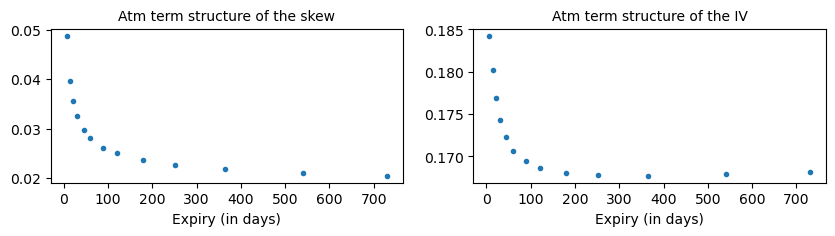

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,2))
ax1.plot(df_term_struct["dte"], np.abs(df_term_struct["skew"]), '.')
ax2.plot(df_term_struct["dte"], df_term_struct["iv"], '.')
ax1.set(xlabel='Expiry (in days)')
ax2.set(xlabel='Expiry (in days)')
ax1.set_title("Atm term structure of the skew", fontsize=10)
ax2.set_title("Atm term structure of the IV", fontsize=10)
plt.show()

### Trying on a log scale

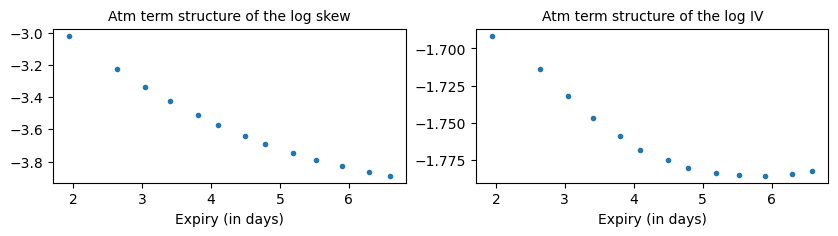

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,2))
ax1.plot(np.log(df_term_struct["dte"]), np.log(np.abs(df_term_struct["skew"])), '.')
ax2.plot(np.log(df_term_struct["dte"]), np.log(df_term_struct["iv"]), '.')
ax1.set(xlabel='Expiry (in days)')
ax2.set(xlabel='Expiry (in days)')
ax1.set_title("Atm term structure of the log skew", fontsize=10)
ax2.set_title("Atm term structure of the log IV", fontsize=10)
plt.show()

This clearly suggests that
$$
\log(\psi(\tau)) \approx -\alpha \log(\tau) + c
\qquad\text{or equivalently}\qquad
\psi(\tau) \approx \frac{\widetilde{c}}{\tau^{\alpha}},
$$
with $\widetilde{c} = \exp\{c\}$.

### Estimating $\alpha$ by linear regression

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

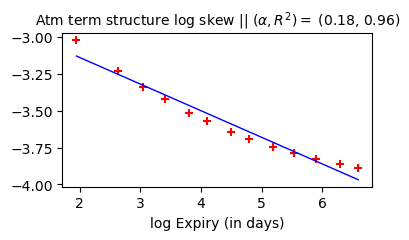

In [15]:
log_term_struc = np.log(df_term_struct["dte"].values).reshape(-1, 1)
y = np.array(np.log(np.abs(df_term_struct["skew"].values))).reshape(-1, 1)

regr = LinearRegression()
regr.fit(log_term_struc,y)
regrCoef = regr.coef_[0][0]
regrInterc = regr.intercept_[0]
regr_rsquared = r2_score(y, regr.predict(log_term_struc))

plt.figure(figsize=(4,2))
plt.scatter(log_term_struc, y, marker="+", c='red')
plt.plot(log_term_struc, regr.predict(log_term_struc), c='blue', linewidth=1)
plt.xlabel("log Expiry (in days)", fontsize=10)
plt.title(r'Atm term structure log skew || $(\alpha, R^2)=$ (%.2f, %.2f)' %(-regrCoef,regr_rsquared), fontsize=10)
plt.show()

### Checking for shorter expiries only

In [16]:
print("List of expiries (in days):", df_term_struct["dte"].values)

List of expiries (in days): [  7  14  21  30  45  60  90 120 180 252 365 540 730]


In [19]:
days_trunc = 22
df_term_struct_trunc = df_term_struct[df_term_struct["dte"] < days_trunc]

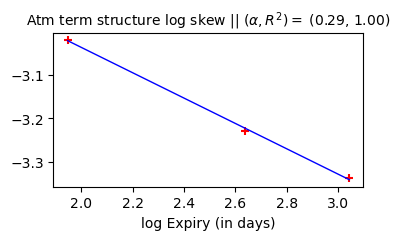

In [20]:
log_term_struc = np.log(df_term_struct_trunc["dte"].values).reshape(-1, 1)
y = np.array(np.log(np.abs(df_term_struct_trunc["skew"].values))).reshape(-1, 1)

regr = LinearRegression()
regr.fit(log_term_struc,y)
regrCoef = regr.coef_[0][0]
regrInterc = regr.intercept_[0]
regr_rsquared = r2_score(y, regr.predict(log_term_struc))

plt.figure(figsize=(4,2))
plt.scatter(log_term_struc, y, marker="+", c='red')
plt.plot(log_term_struc, regr.predict(log_term_struc), c='blue', linewidth=1)
plt.xlabel("log Expiry (in days)", fontsize=10)
plt.title(r'Atm term structure log skew || $(\alpha, R^2)=$ (%.2f, %.2f)' %(-regrCoef,regr_rsquared), fontsize=10)
plt.show()

In [21]:
_alphas, _rsquared = [], []

for ticker in list_tickers:
    df = df_all[df_all["ticker"] == ticker]
    df_term_struct = atm_term_structure(df)
    df_term_struct_trunc = df_term_struct[df_term_struct["dte"] < days_trunc]

    log_term_struc = np.log(df_term_struct_trunc["dte"].values).reshape(-1, 1)
    y = np.array(np.log(np.abs(df_term_struct_trunc["skew"].values))).reshape(-1, 1)

    regr = LinearRegression()
    regr.fit(log_term_struc,y)
    regrCoef = regr.coef_[0][0]
    regrInterc = regr.intercept_[0]
    regr_rsquared = r2_score(y, regr.predict(log_term_struc))
    _alphas.append(-regrCoef)
    _rsquared.append(regr_rsquared)

df_rSquared = pd.DataFrame({
    "Ticker": list_tickers,
    "alpha": _alphas,
    "RSquared": _rsquared})

df_rSquared.head()

,Ticker,alpha,RSquared
0,SPY,0.290026,0.999094
1,AAPL,0.323912,0.999330
2,GLD,0.246853,0.998466
3,TLT,0.191348,0.998023
4,XOM,0.304731,0.999106


**Theorem:** In a *rough* volatility model,
$\psi(\tau) \sim \frac{C}{\tau^{\half-H}}$, as $\tau\downarrow 0$.


Identifying with $\alpha$ as above yields $\half-H = \alpha$, or $H = \half-\alpha$.

In [22]:
_H = [.5-a for a in _alphas]
pd.DataFrame({
    "Ticker": list_tickers,
    "alpha": _alphas,
    "H": np.round(_H, 2)}).head()

,Ticker,alpha,H
0,SPY,0.290026,0.21
1,AAPL,0.323912,0.18
2,GLD,0.246853,0.25
3,TLT,0.191348,0.31
4,XOM,0.304731,0.20


Not as small as $H\approx 0.1$ (in the $\PP$ world), but definitely smaller than $\half$ (classical stochastic volatility models).

**Next steps:**
- Extensive options data analysis;
- Full rough stochastic volatility specifications;
- Rough *local* stochastic volatility;
- Refined numerics.....
- Implications for barrier options, American options, hedging properties,......

# Indicative references

- **C. Bayer, P.K. Friz, J. Gatheral**. Pricing under rough volatility. *Quantitative Finance*, 2016.
- **O. Bonesini, A. Jacquier, A. Muguruza**. Risk premium and rough volatility. *Frontiers of Mathematical Finance*, 2025.
- **M. Bennedsen, A. Lunde, M. S. Pakkanen**. Hybrid scheme for Brownian semistationary processes. *Finance and Stochastics*, 2017.
- **M. El Amrani, J. Guyon**. Does the term structure of equity at-the-money skew really follow
a power law. *Risk*, 2023.
- **M. Fukasawa**. Short-time at-the-money skew and rough fractional volatility. *Quantitative Finance*, 2017.
- **M. Fukasawa**. Volatility has to be rough. *Quantitative Finance*, 2021.
- **C. Bayer, P.K. Friz, M. Fukasawa, J. Gatheral, A. Jacquier, M. Rosenbaum**. Rough volatility. *SIAM*, 2023.
- **S. De Marco, J. Delemotte, F. Segonne**. Yet another analysis of the SP500 at-the-money skew: crossover of different power-law behaviours, 2023.